Starting Training on cuda...
Epoch 1/50 | T_Loss: 0.2757 | V_Dice: 0.0000
Epoch 2/50 | T_Loss: 0.2486 | V_Dice: 0.0000
Epoch 3/50 | T_Loss: 0.2215 | V_Dice: 0.0050
Epoch 4/50 | T_Loss: 0.2086 | V_Dice: 0.0990
Epoch 5/50 | T_Loss: 0.2014 | V_Dice: 0.1088
Epoch 6/50 | T_Loss: 0.1973 | V_Dice: 0.1677
Epoch 7/50 | T_Loss: 0.1956 | V_Dice: 0.1799
Epoch 8/50 | T_Loss: 0.1904 | V_Dice: 0.1423
Epoch 9/50 | T_Loss: 0.1820 | V_Dice: 0.2036
Epoch 10/50 | T_Loss: 0.1756 | V_Dice: 0.1340
Epoch 11/50 | T_Loss: 0.1649 | V_Dice: 0.3005
Epoch 12/50 | T_Loss: 0.1533 | V_Dice: 0.3061
Epoch 13/50 | T_Loss: 0.1383 | V_Dice: 0.2607
Epoch 14/50 | T_Loss: 0.1232 | V_Dice: 0.3567
Epoch 15/50 | T_Loss: 0.1072 | V_Dice: 0.3693
Epoch 16/50 | T_Loss: 0.0898 | V_Dice: 0.3429
Epoch 17/50 | T_Loss: 0.0767 | V_Dice: 0.3756
Epoch 18/50 | T_Loss: 0.0611 | V_Dice: 0.4259
Epoch 19/50 | T_Loss: 0.0485 | V_Dice: 0.4347
Epoch 20/50 | T_Loss: 0.0400 | V_Dice: 0.4284
Epoch 21/50 | T_Loss: 0.0310 | V_Dice: 0.4485
Epoch 22/50 | 

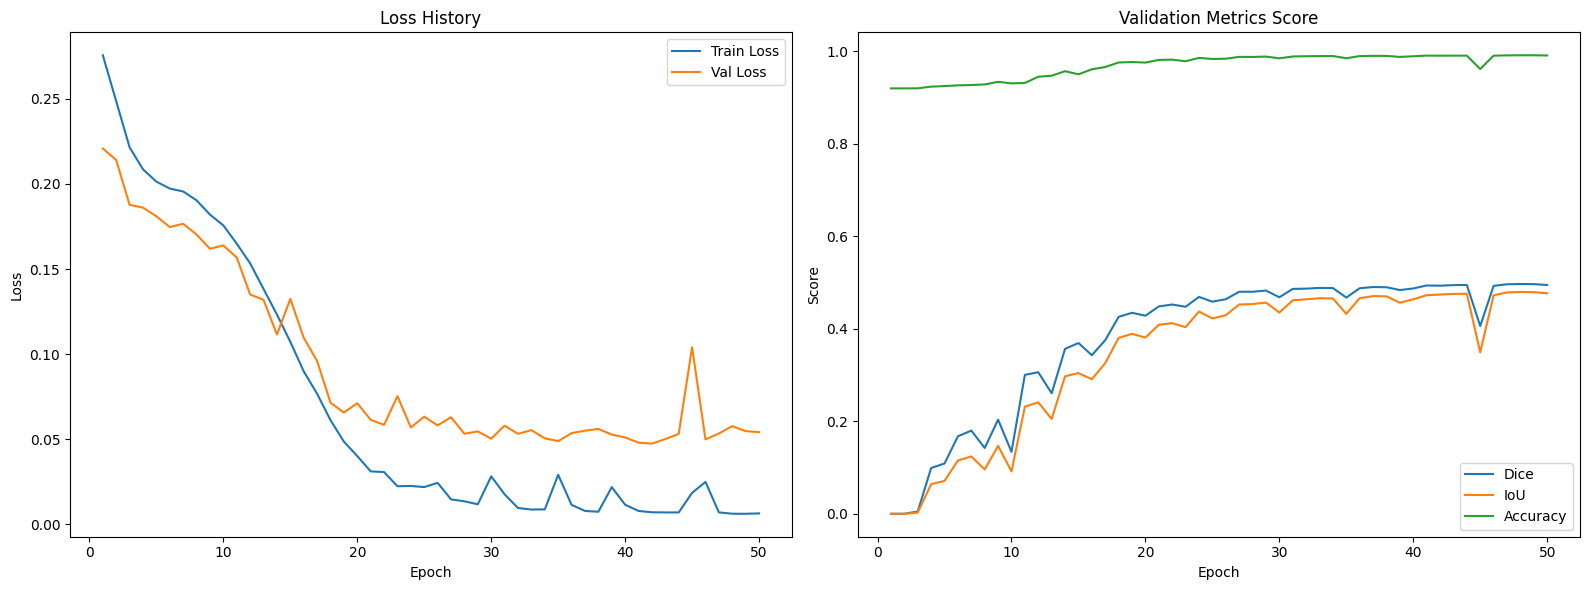

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 1. DATASET CLASS (Supports JPG and PNG)
# ==========================================
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        
        # Define supported extensions (case-insensitive)
        exts = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
        
        self.image_paths = []
        for e in exts:
            self.image_paths.extend(glob(os.path.join(image_dir, e)))
        
        self.mask_paths = []
        for e in exts:
            self.mask_paths.extend(glob(os.path.join(mask_dir, e)))
            
        # Sort to ensure images and masks match up
        self.image_paths.sort()
        self.mask_paths.sort()
        
        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {image_dir}")
        if len(self.image_paths) != len(self.mask_paths):
            print(f"Warning: Found {len(self.image_paths)} images and {len(self.mask_paths)} masks.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Read Image and convert to RGB
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Read Mask as Grayscale
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Resize
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256))

        # Normalize and HWC -> CHW
        image = image.transpose((2, 0, 1)) / 255.0
        mask = mask[np.newaxis, ...] / 255.0

        return torch.tensor(image, dtype=torch.float32), \
               torch.tensor(mask, dtype=torch.float32)

# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def CBR(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = CBR(3, 64)
        self.enc2 = CBR(64, 128)
        self.enc3 = CBR(128, 256)
        self.enc4 = CBR(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = CBR(512, 1024)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = CBR(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = CBR(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = CBR(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = CBR(128, 64)
        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.upconv4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return torch.sigmoid(self.final(d1))

# ==========================================
# 3. METRIC CALCULATION HELPER
# ==========================================
def calculate_metrics(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    target = (target > 0.5).float()
    
    tp = (pred * target).sum().item()
    fp = (pred * (1 - target)).sum().item()
    fn = ((1 - pred) * target).sum().item()
    tn = ((1 - pred) * (1 - target)).sum().item()
    
    eps = 1e-7
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    
    return {
        "accuracy": accuracy, "precision": precision, "recall": recall,
        "f1": f1, "iou": iou, "dice": dice
    }

# ==========================================
# 4. MAIN TRAINING LOOP
# ==========================================
def train_and_evaluate():
    # Paths
    image_dir = r'D:\Biose\Train\DatasetOG\Dataset\image'
    mask_dir = r'D:\Biose\Train\DatasetOG\Dataset\label'

    # Hyperparameters
    batch_size = 4
    lr = 1e-4
    epochs = 50
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Data Setup
    full_dataset = SegmentationDataset(image_dir, mask_dir)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

    # Model Initialization
    model = UNet().to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    print(f"Starting Training on {device}...")

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss = 0
        train_m = {"accuracy": 0, "precision": 0, "recall": 0, "f1": 0, "iou": 0, "dice": 0}

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            metrics = calculate_metrics(outputs, masks)
            for k in train_m: train_m[k] += metrics[k]

        # Validation Phase
        model.eval()
        val_loss = 0
        val_m = {"accuracy": 0, "precision": 0, "recall": 0, "f1": 0, "iou": 0, "dice": 0}

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                metrics = calculate_metrics(outputs, masks)
                for k in val_m: val_m[k] += metrics[k]

        # Averaging
        n_t, n_v = len(train_loader), len(val_loader)
        epoch_data = {
            "epoch": epoch + 1,
            "train_loss": train_loss / n_t,
            "val_loss": val_loss / n_v,
            **{f"train_{k}": v / n_t for k, v in train_m.items()},
            **{f"val_{k}": v / n_v for k, v in val_m.items()}
        }
        history.append(epoch_data)

        print(f"Epoch {epoch+1}/{epochs} | T_Loss: {epoch_data['train_loss']:.4f} | V_Dice: {epoch_data['val_dice']:.4f}")

    # Save to CSV
    df = pd.DataFrame(history)
    df.to_csv("training_metrics_results.csv", index=False)
    print("Metrics saved to training_metrics_results.csv")
    
    # Save Model
    torch.save(model.state_dict(), "final_unet_model.pth")
    
    return df

# ==========================================
# 5. PLOTTING FUNCTION
# ==========================================
def plot_results(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Loss
    ax1.plot(df['epoch'], df['train_loss'], label='Train Loss')
    ax1.plot(df['epoch'], df['val_loss'], label='Val Loss')
    ax1.set_title('Loss History')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot Metrics (Validation)
    ax2.plot(df['epoch'], df['val_dice'], label='Dice')
    ax2.plot(df['epoch'], df['val_iou'], label='IoU')
    ax2.plot(df['epoch'], df['val_accuracy'], label='Accuracy')
    ax2.set_title('Validation Metrics Score')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('training_plots.png')
    plt.show()

# Run the process
if __name__ == "__main__":
    results_df = train_and_evaluate()
    plot_results(results_df)